# Activation Functions Comparison


In this notebook we compare how four activation functions (tanh, ReLU, GELU, Swish) affect the training and approximation accuracy of a shallow neural network with one hidden layer and different numbers of hidden neurons (2, 5, 7, 10) when approximating $ f(x) = x^2 $ over $ [−1,1] $ .

Activation functions to compare:
- **Tanh**: Smooth, zero-centered, may produce smooth approximations but struggle with few neurons or converge slowly.
- **ReLU**: Non-smooth, forms piecewise linear approximations, potentially jagged with few neurons.
- **GELU**: Smooth, modern, balances smoothness and expressivity, likely performs well across neuron counts.
- **Swish**: Smooth, non-monotonic, may converge quickly and fit $ x^2 $ accurately.

Import libraries

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

Target function

In [21]:
def target_function(x):
    return x**2

Generate data (50 points)

In [22]:
x_data = np.linspace(-1, 1, 50).reshape(-1, 1)
y_data = target_function(x_data)
x_tensor = torch.FloatTensor(x_data)
y_tensor = torch.FloatTensor(y_data)

Shallow neural network with one hidden layer

In [23]:
class ShallowNet(nn.Module):
    def __init__(self, hidden, activation):
        super().__init__()
        self.hidden = nn.Linear(1, hidden)
        self.out = nn.Linear(hidden, 1)
        # Set activation function
        if activation == "tanh":
            self.activation = torch.tanh
        elif activation == "relu":
            self.activation = torch.relu
        elif activation == "gelu":
            self.activation = nn.GELU()
        elif activation == "swish":
            self.activation = nn.SiLU()
        else:
            raise ValueError("Unsupported activation function")

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.out(x)
        return x

Training function

In [24]:
def train_model(model, x_train, y_train, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    return train_losses

Run experiment for each activation function and neuron count

In [25]:
activations = ["tanh", "relu", "gelu", "swish"]
neuron_counts = [2, 3, 5, 7, 10]
results = {n: {} for n in neuron_counts}
models = {n: {} for n in neuron_counts}

for n in neuron_counts:
    for act in activations:
        model = ShallowNet(hidden=n, activation=act)
        train_losses = train_model(model, x_tensor, y_tensor)
        results[n][act] = train_losses
        models[n][act] = model

Plot function approximations

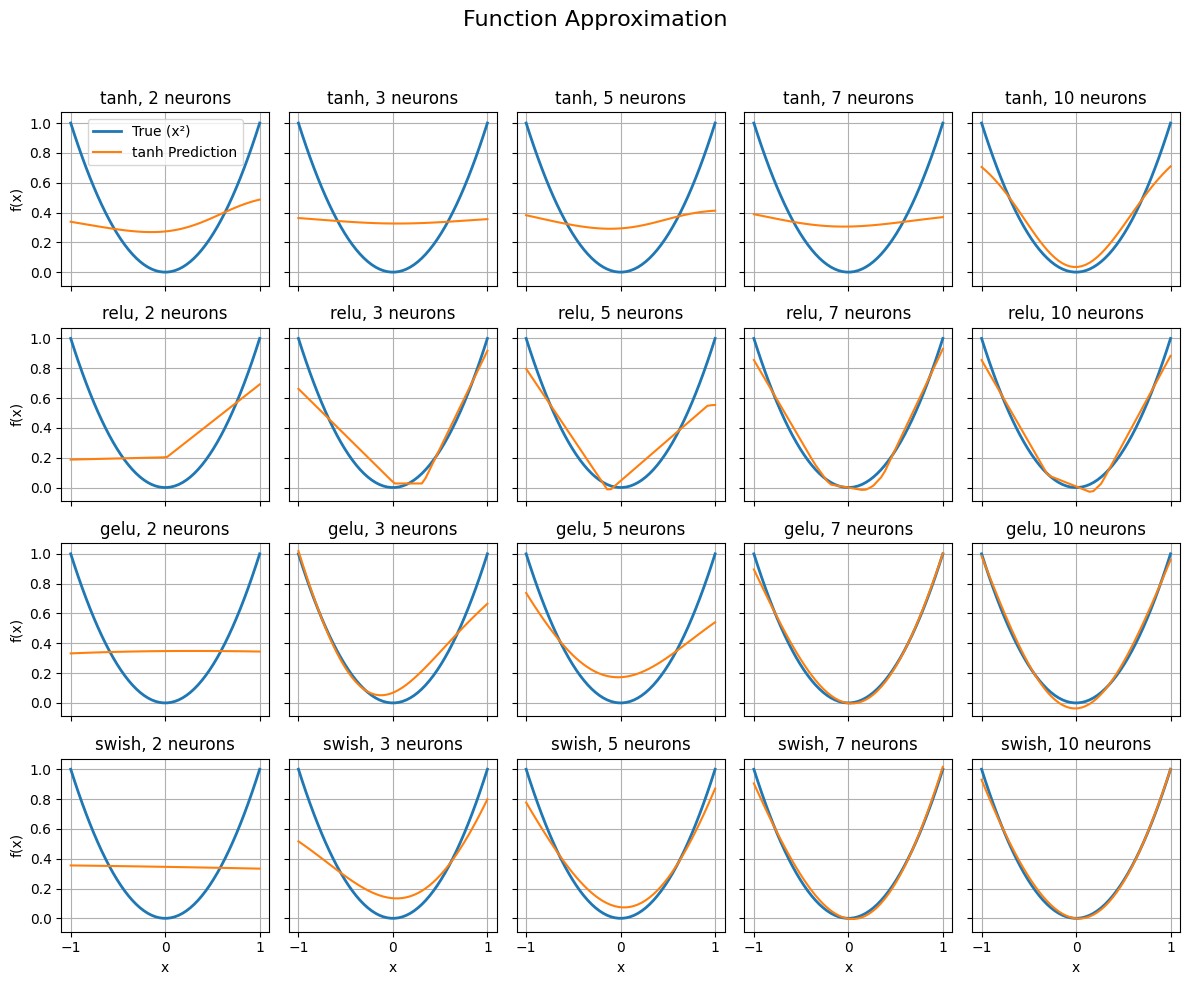

In [26]:
fig, axes = plt.subplots(nrows=len(activations), ncols=len(neuron_counts), figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle("Function Approximation", fontsize=16)

for i, act in enumerate(activations):
    for j, n in enumerate(neuron_counts):
        ax = axes[i, j]
        ax.plot(x_data, y_data, label="True (x²)", linewidth=2)
        models[n][act].eval()
        with torch.no_grad():
            y_pred = models[n][act](x_tensor).numpy()
        ax.plot(x_data, y_pred, label=f"{act} Prediction")
        ax.set_title(f"{act}, {n} neurons")
        ax.grid(True)
        if i == 0 and j == 0:
            ax.legend()
        if i == 3:
            ax.set_xlabel("x")
        if j == 0:
            ax.set_ylabel("f(x)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Plot loss curves

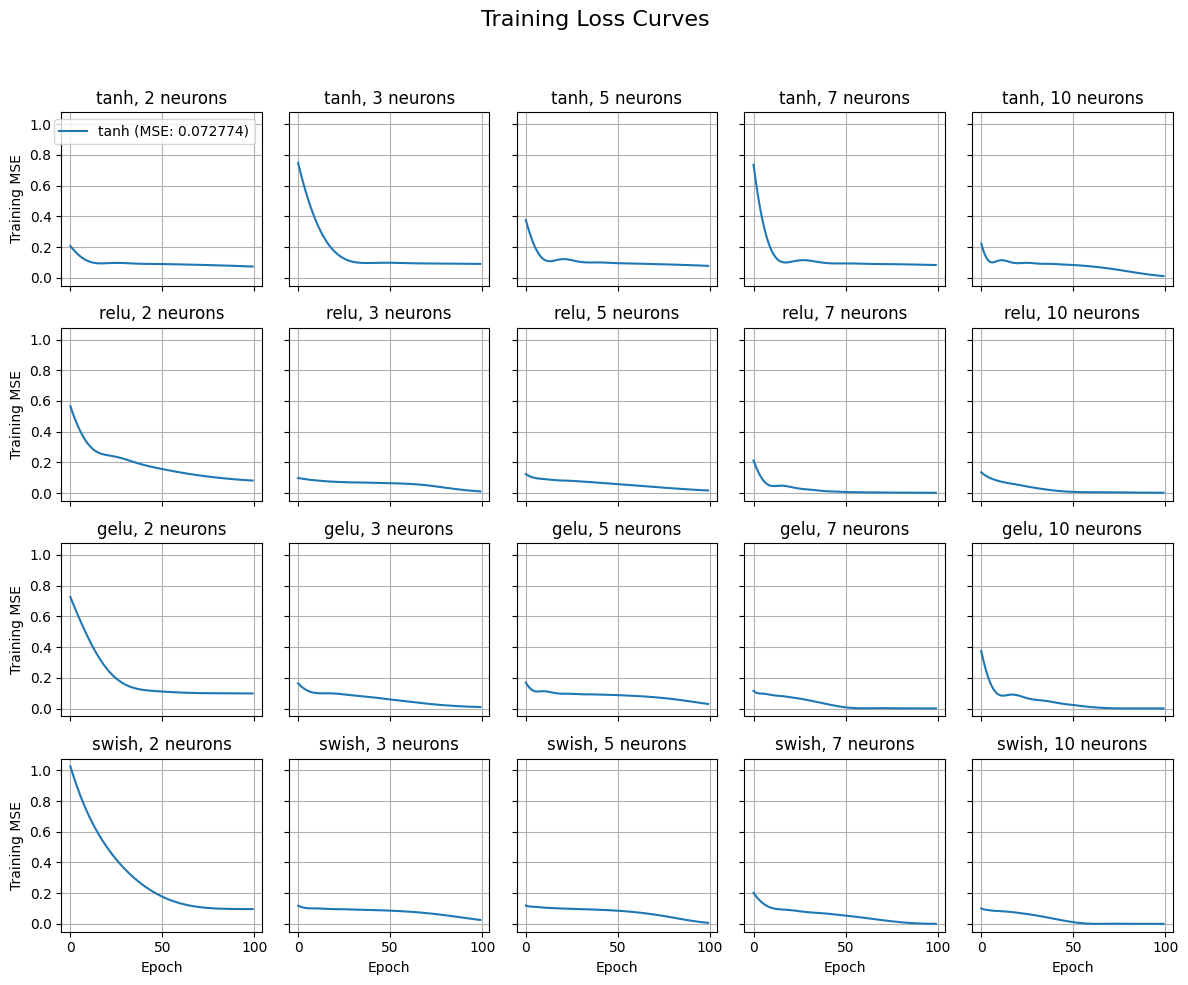

In [27]:
fig, axes = plt.subplots(nrows=len(activations), ncols=len(neuron_counts), figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle("Training Loss Curves", fontsize=16)

for i, act in enumerate(activations):
    for j, n in enumerate(neuron_counts):
        ax = axes[i, j]
        ax.plot(results[n][act], label=f"{act} (MSE: {results[n][act][-1]:.6f})")
        ax.set_title(f"{act}, {n} neurons")
        ax.grid(True)
        if i == 0 and j == 0:
            ax.legend()
        if i == 3:
            ax.set_xlabel("Epoch")
        if j == 0:
            ax.set_ylabel("Training MSE")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()